# Exploratory Data Analysis

Note that EDA was also performed in EDA.sql

In [32]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from data_profiling import ProfileReport

### Connect to Database

In [15]:
load_dotenv()
db_path : str | None = os.getenv('DATABASE_LOC')

if db_path is None:
    raise ValueError("DATABASE_LOC environment variable is not set.")
con = sqlite3.connect(db_path)

df = pd.read_sql_query('SELECT * FROM ecommerce', con)

### Data Overview

In [3]:
df.head()

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-24 19:16:21 UTC,2294584263154074236,2273948316817424439,2268105471367840086,,karcher,217.57,1515915625443148002


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2633521 entries, 0 to 2633520
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   order_id       object 
 2   product_id     object 
 3   category_id    object 
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        object 
dtypes: float64(1), object(7)
memory usage: 160.7+ MB


In [5]:
df.describe(include='all')

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
count,2633521,2633521,2633521,2633521,2633521,2633521,2.201567e+06,2201567
unique,1316174,1435266,25113,928,511,23022,NaN,233835
top,1970-01-01 00:33:40 UTC,2388440981134393883,1515966223523303302,,,,NaN,
freq,19631,61,44491,431954,612202,506005,NaN,1637398
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.540932e+02,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2.419421e+02,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.456000e+01,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,5.553000e+01,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.967400e+02,NaN


In [6]:
df[df.duplicated()]

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
7,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2268105428166508982,electronics.smartphone,apple,1387.01,1515915625448766480
8,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2268105428166508982,electronics.smartphone,apple,1387.01,1515915625448766480
9,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2268105428166508982,electronics.smartphone,apple,1387.01,1515915625448766480
...,...,...,...,...,...,...,...,...
2623318,2020-11-19 17:11:05 UTC,2388440981134688081,2388434452474178202,2268105430162997728,electronics.audio.headphone,hyperx,74.05,1515915625514628427
2632704,2020-11-20 07:34:17 UTC,2388440981134693250,1515966223509089405,2268105428166508982,electronics.smartphone,apple,208.31,1515915625495363821
2632822,2020-11-20 09:52:06 UTC,2388440981134693354,2309018260105855661,2268105649281827258,,palisad,1.37,1515915625475787153
2633140,2020-11-20 18:23:21 UTC,2388440981134693620,2388434452476503038,2268105428166508982,electronics.smartphone,apple,856.23,1515915625514627882


In [7]:
df.isna().sum()

event_time            0
order_id              0
product_id            0
category_id           0
category_code         0
brand                 0
price            431954
user_id          431954
dtype: int64

In [8]:
df.isna().sum().sum()

np.int64(863908)

### Feature Assessment

#### Univariate Analysis

Generate a minimal ydata_profiling report that can be found in ecommerce_profile_report.html

In [10]:
profile = ProfileReport(df, title="Profile Report", minimal=True)
profile.to_file("ecommerce_profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 45.83it/s]


##### Event Time

In [16]:
df['event_time'] = pd.to_datetime(df['event_time'], format='%Y-%m-%d %H:%M:%S UTC')

In [19]:
df['event_time'].describe()

count                          2633521
mean     2020-01-16 19:57:05.412119808
min                1970-01-01 00:33:40
25%                2020-03-05 15:42:44
50%                2020-06-08 08:33:27
75%                2020-08-24 06:52:14
max                2020-11-21 10:10:30
Name: event_time, dtype: object

In [18]:
df['event_time'].value_counts().head(10)

event_time
1970-01-01 00:33:40    19631
2020-04-09 16:30:01      349
2020-04-08 16:30:01      341
2020-04-25 12:00:00      291
2020-04-06 16:30:01      288
2020-04-05 16:30:01      223
2020-04-04 16:30:01      216
2020-03-27 16:30:01      208
2020-03-28 16:30:01      208
2020-04-07 16:30:01      200
Name: count, dtype: int64

In [28]:
df_event_time_exclude_1970 = df[df['event_time'] > pd.Timestamp('1970-01-01 00:33:40')]

In [29]:
df_event_time_exclude_1970.describe()

,event_time,price
count,2613890,2.186014e+06
mean,2020-06-02 02:27:31.491581440,1.541946e+02
min,2020-01-05 03:26:46,0.000000e+00
25%,2020-03-06 15:38:31,1.456000e+01
50%,2020-06-09 05:56:07,5.553000e+01
75%,2020-08-24 08:59:28.750000128,1.967400e+02
max,2020-11-21 10:10:30,5.092590e+04
std,NaN,2.420310e+02


In [30]:
day_range = df_event_time_exclude_1970['event_time'].max() - df_event_time_exclude_1970['event_time'].min()
day_range

Timedelta('321 days 06:43:44')

Text(0.5, 1.0, 'Distribution of Event Time (Excluding 1970)')

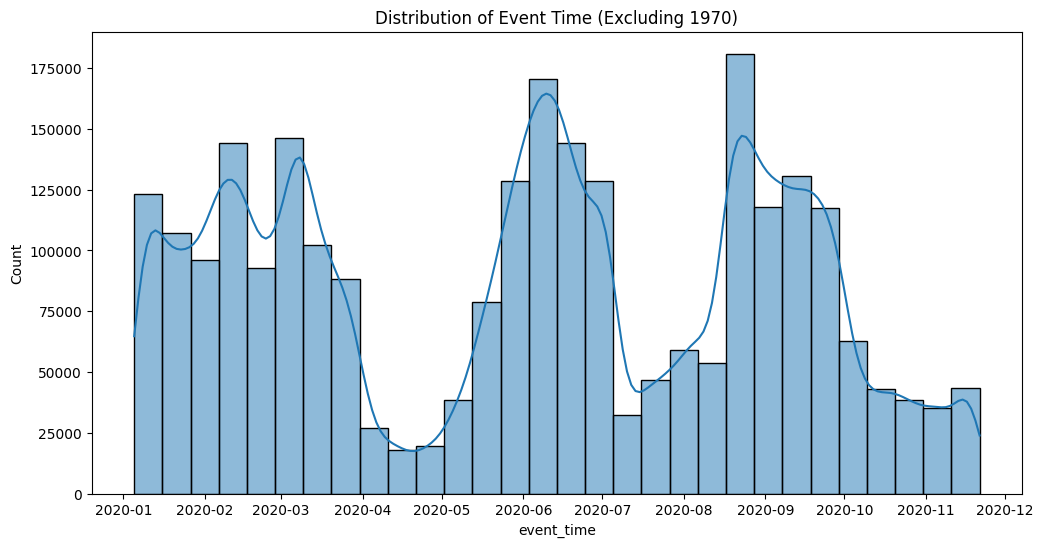

In [36]:
plt.figure(figsize=(12, 6))
sns.histplot(x=df_event_time_exclude_1970['event_time'], bins=30, kde=True)
plt.title('Distribution of Event Time (Excluding 1970)')

##### Category Code

In [39]:
df[df['category_code'].str.len() == 0]

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
4,2020-04-24 19:16:21,2294584263154074236,2273948316817424439,2268105471367840086,,karcher,217.57,1515915625443148002
16,2020-04-28 02:21:45,2296972701060825130,1515966223509104683,2268105402774193030,,philips,23.13,1515915625451212869
18,2020-04-28 04:25:00,2297034737199350540,1515966223509719628,2268105635507732512,,,6.94,1515915625447779982
19,2020-04-28 04:25:00,2297034737199350540,1515966223509719628,2268105635507732512,,,6.94,1515915625447779982
25,2020-04-29 03:25:12,2297729407910937541,1515966223509105105,2268105427528974760,,sbs,0.02,1515915625441708399
...,...,...,...,...,...,...,...,...
2633496,2020-11-21 09:50:24,2388440981134693925,1515966223513916332,2268105441487618770,,ava,78.68,1515915625492420628
2633502,2020-11-21 09:59:01,2388440981134693930,1515966223510177554,2268105424601350500,,dji,0.23,1515915625513946151
2633503,2020-11-21 09:59:01,2388440981134693930,2273948237628965713,2268105424601350500,,dji,0.23,1515915625513946151
2633513,2020-11-21 10:08:14,2388440981134693940,2273948246856434093,2268105407404704746,,xiaomi,16.18,1515915625470243155


In [42]:
df['category_code'].str.len().value_counts().sort_index()

category_code
0     612202
4     174324
5     255203
6       2398
7         29
9       1768
10       764
11      2360
12       317
13      7380
14      1743
15     53800
16      5256
17      2506
18    132156
19     10718
20     71745
21     14444
22    358685
23    117137
24    105465
25    139153
26     82844
27    127770
28     41220
29    109315
30     29245
31     33871
32     78536
33     16704
35     15982
38     28481
Name: count, dtype: int64

In [48]:
df['category_code'].str.len().value_counts(normalize=True).sort_index().round(2)

category_code
0     0.23
4     0.07
5     0.10
6     0.00
7     0.00
9     0.00
10    0.00
11    0.00
12    0.00
13    0.00
14    0.00
15    0.02
16    0.00
17    0.00
18    0.05
19    0.00
20    0.03
21    0.01
22    0.14
23    0.04
24    0.04
25    0.05
26    0.03
27    0.05
28    0.02
29    0.04
30    0.01
31    0.01
32    0.03
33    0.01
35    0.01
38    0.01
Name: proportion, dtype: float64

##### brand

In [49]:
df['brand'].str.len().value_counts().sort_index()

brand
0     506005
2      75588
3     215779
4     186300
5     387542
6     243452
7     668427
8     155524
9      90621
10     29163
11     29336
12       136
13         1
14         7
16      7021
19     38619
Name: count, dtype: int64

In [51]:
df['brand'].str.len().value_counts(normalize=True).sort_index().round(2)

brand
0     0.19
2     0.03
3     0.08
4     0.07
5     0.15
6     0.09
7     0.25
8     0.06
9     0.03
10    0.01
11    0.01
12    0.00
13    0.00
14    0.00
16    0.00
19    0.01
Name: proportion, dtype: float64

In [50]:
df[df['brand'].str.len() == 0]

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
18,2020-04-28 04:25:00,2297034737199350540,1515966223509719628,2268105635507732512,,,6.94,1515915625447779982
19,2020-04-28 04:25:00,2297034737199350540,1515966223509719628,2268105635507732512,,,6.94,1515915625447779982
61,2020-04-29 12:42:12,2298009757589438761,1515966223509104974,2268105406356128718,computers.peripherals.keyboard,,12.71,1515915625451999752
64,2020-04-29 12:42:12,2298009757589438761,1515966223509104402,2268105409317306388,,,300.90,1515915625451999752
69,2020-04-29 12:51:50,2298014603872830244,1515966223509089420,2268105406549066706,computers.peripherals.mouse,,5.07,1515915625452183601
...,...,...,...,...,...,...,...,...
2633316,2020-11-21 06:01:36,2388440981134693769,1515966223532411322,2268105409317306388,,,400.44,1515915625444844659
2633318,2020-11-21 06:03:17,2388440981134693771,2333247274437574677,2268105404862956464,furniture.kitchen.table,,27.75,1515915625449306918
2633361,2020-11-21 06:48:38,2388440981134693809,1515966223509266682,2268105440455819964,,,49.75,1515915625514874517
2633396,2020-11-21 07:34:31,2388440981134693841,1515966223510196871,2268105428854374854,electronics.clocks,,6.92,1515915625514876070


In [53]:
df[df['brand'].str.len() > 0]

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-24 19:16:21,2294584263154074236,2273948316817424439,2268105471367840086,,karcher,217.57,1515915625443148002
...,...,...,...,...,...,...,...,...
2633516,2020-11-21 10:10:01,2388440981134693942,1515966223526602848,2268105428166508982,electronics.smartphone,oppo,138.87,1515915625514888605
2633517,2020-11-21 10:10:13,2388440981134693943,1515966223509089282,2268105428166508982,electronics.smartphone,apple,418.96,1515915625514891148
2633518,2020-11-21 10:10:30,2388440981134693944,1515966223509089917,2268105402447037312,appliances.personal.scales,vitek,12.48,1515915625514834281
2633519,2020-11-21 10:10:30,2388440981134693944,2273948184839454837,2268105440371933882,,moulinex,41.64,1515915625514834281


#### Bivariate Analysis

In [54]:
df_bivariate = df
df_bivariate['event_time'] = df_event_time_exclude_1970['event_time']
df_bivariate.head()

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-24 19:16:21,2294584263154074236,2273948316817424439,2268105471367840086,,karcher,217.57,1515915625443148002


In [56]:
df_bivariate.dtypes

event_time       datetime64[ns]
order_id                 object
product_id               object
category_id              object
category_code            object
brand                    object
price                   float64
user_id                  object
dtype: object